# 03 L1B Waveform Features vs Refh Quality

This is the main analysis notebook for waveform-derived diagnostic features. It reads the outputs of `extract_waveform_features.py` and studies how those features relate to `refh_snr`, `good_snr`, sweep-level artifact hypotheses, and transferred 3DEP pseudo-labels when available.

In [1]:
from pathlib import Path
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_casals_l1b_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "waveform_components.py").exists():
            return candidate
        if (candidate / "CASALS_L1B" / "waveform_components.py").exists():
            return candidate / "CASALS_L1B"
    raise FileNotFoundError("Could not locate CASALS_L1B directory from the current notebook working directory.")


CASALS_L1B_DIR = find_casals_l1b_root()
if str(CASALS_L1B_DIR) not in sys.path:
    sys.path.insert(0, str(CASALS_L1B_DIR))

import laspy
from waveform_components import build_record_index_grid, classify_prominent_components, detect_candidate_components_1d, read_optional_1d, read_sweep_matrix

H5_STEM = "casals_l1b_20241118T171757_001_02"
OUTPUT_DIR = CASALS_L1B_DIR / "outputs" / "extract_waveform_features" / H5_STEM
PULSE_PATH = OUTPUT_DIR / "pulse_summary.parquet"
COMPONENT_PATH = OUTPUT_DIR / "component_table.parquet"
SWEEP_PATH = OUTPUT_DIR / "sweep_summary.csv"

missing = [path for path in [PULSE_PATH, COMPONENT_PATH, SWEEP_PATH] if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Waveform feature outputs were not found. Run extract_waveform_features.py with a sample config such as:\n"
        "Config(input_h5_paths=[Path('./casals_h5_downloads/casals_l1b_20241118T171757_001_02.h5')], sweep_start=5000, sweep_end=5002)"
    )

In [2]:
pulse_df = pd.read_parquet(PULSE_PATH)
component_df = pd.read_parquet(COMPONENT_PATH)
sweep_df = pd.read_csv(SWEEP_PATH)

print("processed pulses:", len(pulse_df))
print("processed sweeps:", len(sweep_df))
print("good_snr fraction:", pulse_df["good_snr"].astype("Float64").mean())
print("reliability class counts:")
display(pulse_df["waveform_reliability_class"].value_counts(dropna=False).to_frame("count"))
print("candidate vs prominent components:")
display(
    pd.Series(
        {
            "mean_n_candidate_components": pulse_df["n_candidate_components"].astype(float).mean(),
            "mean_n_prominent_components": pulse_df["n_prominent_components"].astype(float).mean(),
            "sum_candidate_component_rows": int(component_df.shape[0]),
            "sum_prominent_component_rows": int(component_df["is_prominent_component"].fillna(False).sum()),
        }
    ).to_frame("value")
)

processed pulses: 768
processed sweeps: 3
good_snr fraction: 0.359375
reliability class counts:


,count
waveform_reliability_class,
clear_main_with_secondary_candidate,396
ambiguous_main_peak,201
clear_main_peak,169
no_detected_main_peak,2


candidate vs prominent components:


,value
mean_n_candidate_components,3.989583
mean_n_prominent_components,1.807292
sum_candidate_component_rows,3064.000000
sum_prominent_component_rows,1388.000000


## Main result A: waveform features vs refh_snr

Main peak prominence is usually more stable than raw candidate count. Candidate component count alone should not be treated as a true return count.

main_peak_prominence                            \
                            count       median         mean   
refh_snr_bin                                                  
<3                            258   623.238914   631.716545   
3-5                           232  1000.311214  1013.966775   
5-8                           166  1738.536465  1734.997376   
8-12                           96  2595.212134  2633.875667   
12+                            14  3622.957932  3882.709613   

             main_peak_width_bins                       \
                            count    median       mean   
refh_snr_bin                                             
<3                            258  9.547076  10.755556   
3-5                           232  9.963689  10.848069   
5-8                           166   8.31065    8.87848   
8-12                           96  8.054226   8.103224   
12+                            14  8.270575   8.114082   

             secondary_to_main_prominence_ratio                      
                                          count    median      mean  
refh_snr_bin                                                         
<3                                          134  0.867133  0.846945  
3-5                                         155  0.576711  0.609455  
5-8                                          83  0.339556  0.356911  
8-12                                         24  0.232085  0.237448  
12+                                           0      <NA>      <NA>

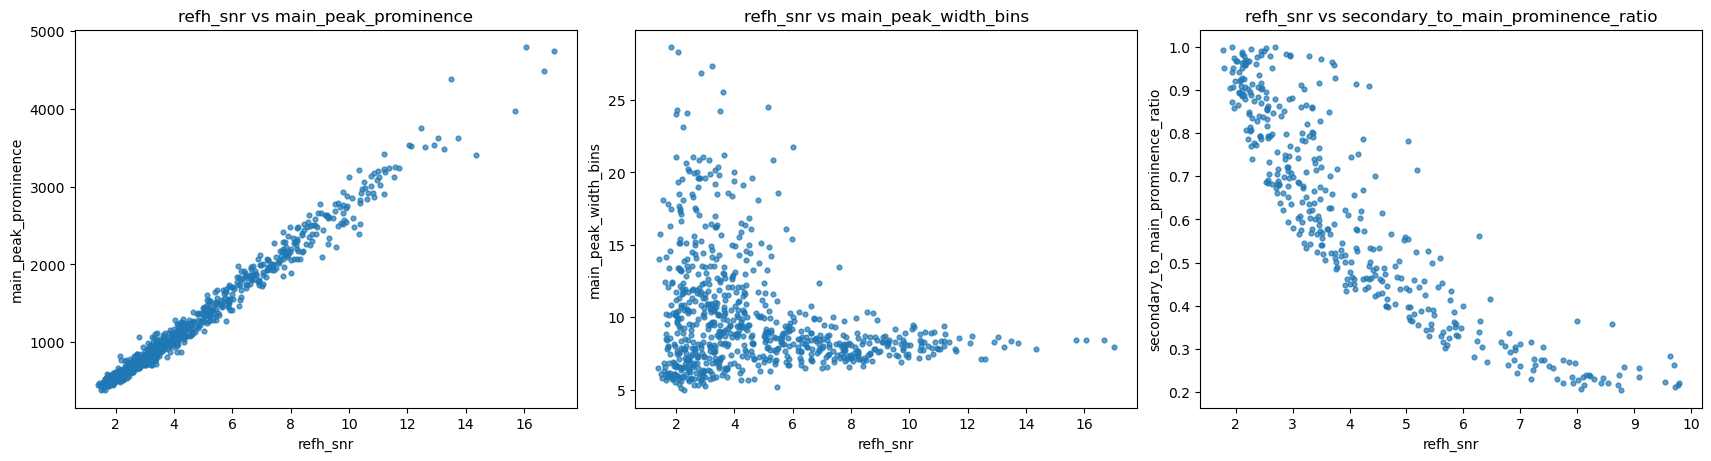

In [3]:
refh_snr_bins = pd.cut(
    pulse_df["refh_snr"],
    bins=[-np.inf, 3, 5, 8, 12, np.inf],
    labels=["<3", "3-5", "5-8", "8-12", "12+"],
)
snr_summary = (
    pulse_df.assign(refh_snr_bin=refh_snr_bins)
    .groupby("refh_snr_bin", observed=False)[["main_peak_prominence", "main_peak_width_bins", "secondary_to_main_prominence_ratio"]]
    .agg(["count", "median", "mean"])
)
display(snr_summary)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
axes[0].scatter(pulse_df["refh_snr"], pulse_df["main_peak_prominence"], s=12, alpha=0.7)
axes[0].set_title("refh_snr vs main_peak_prominence")
axes[0].set_xlabel("refh_snr")
axes[0].set_ylabel("main_peak_prominence")

axes[1].scatter(pulse_df["refh_snr"], pulse_df["main_peak_width_bins"], s=12, alpha=0.7)
axes[1].set_title("refh_snr vs main_peak_width_bins")
axes[1].set_xlabel("refh_snr")
axes[1].set_ylabel("main_peak_width_bins")

axes[2].scatter(pulse_df["refh_snr"], pulse_df["secondary_to_main_prominence_ratio"], s=12, alpha=0.7)
axes[2].set_title("refh_snr vs secondary_to_main_prominence_ratio")
axes[2].set_xlabel("refh_snr")
axes[2].set_ylabel("secondary_to_main_prominence_ratio")
plt.show()

## Main result B: good_snr vs waveform reliability

waveform_reliability_class,ambiguous_main_peak,clear_main_peak,clear_main_with_secondary_candidate,no_detected_main_peak
good_snr,,,,
False,201,0,289,2
True,0,169,107,0


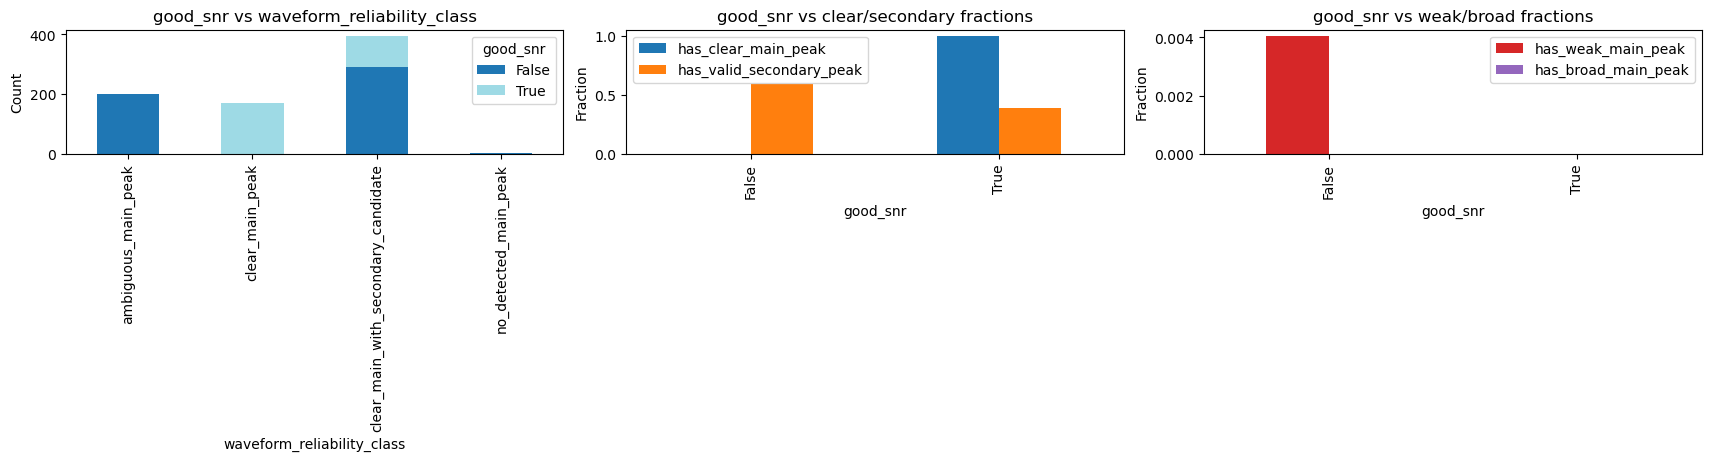

In [4]:
reliability_table = (
    pulse_df.groupby(["good_snr", "waveform_reliability_class"])
    .size()
    .unstack(fill_value=0)
)
display(reliability_table)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
reliability_table.T.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20")
axes[0].set_title("good_snr vs waveform_reliability_class")
axes[0].set_xlabel("waveform_reliability_class")
axes[0].set_ylabel("Count")

comparison = pulse_df.groupby("good_snr")[["has_clear_main_peak", "has_valid_secondary_peak", "has_weak_main_peak", "has_broad_main_peak"]].mean()
comparison[["has_clear_main_peak", "has_valid_secondary_peak"]].plot(kind="bar", ax=axes[1], color=["tab:blue", "tab:orange"])
axes[1].set_title("good_snr vs clear/secondary fractions")
axes[1].set_ylabel("Fraction")

comparison[["has_weak_main_peak", "has_broad_main_peak"]].plot(kind="bar", ax=axes[2], color=["tab:red", "tab:purple"])
axes[2].set_title("good_snr vs weak/broad fractions")
axes[2].set_ylabel("Fraction")
plt.show()

## Main result C: stripe/artifact detection

,h5_filename,sweep_num,n_tracks,n_valid_pulses,median_refh_snr,fraction_good_snr,median_main_peak_prominence,median_main_peak_width_bins,median_n_candidate_components,median_n_prominent_components,fraction_clear_main_peak,fraction_valid_secondary_peak,fraction_weak_main_peak,fraction_broad_main_peak,fixed_bin_mode,fixed_bin_fraction,stripe_like_flag,continuity_median_abs_residual,continuity_p95_abs_residual,continuity_discontinuity_count
0,casals_l1b_20241118T171757_001_02.h5,5000,256,256,3.838088,0.375000,1019.409073,8.571498,4.0,2.0,0.375000,0.535156,0.000000,0.0,1693.0,0.378906,True,1.0,375.5,64
1,casals_l1b_20241118T171757_001_02.h5,5001,256,256,3.919184,0.347656,1048.391920,8.933250,3.0,1.0,0.347656,0.468750,0.003906,0.0,1693.0,0.352941,True,1.0,313.3,75
2,casals_l1b_20241118T171757_001_02.h5,5002,256,256,3.645453,0.355469,995.498153,8.563601,4.0,2.0,0.355469,0.542969,0.003906,0.0,1694.0,0.321569,True,1.0,761.2,75


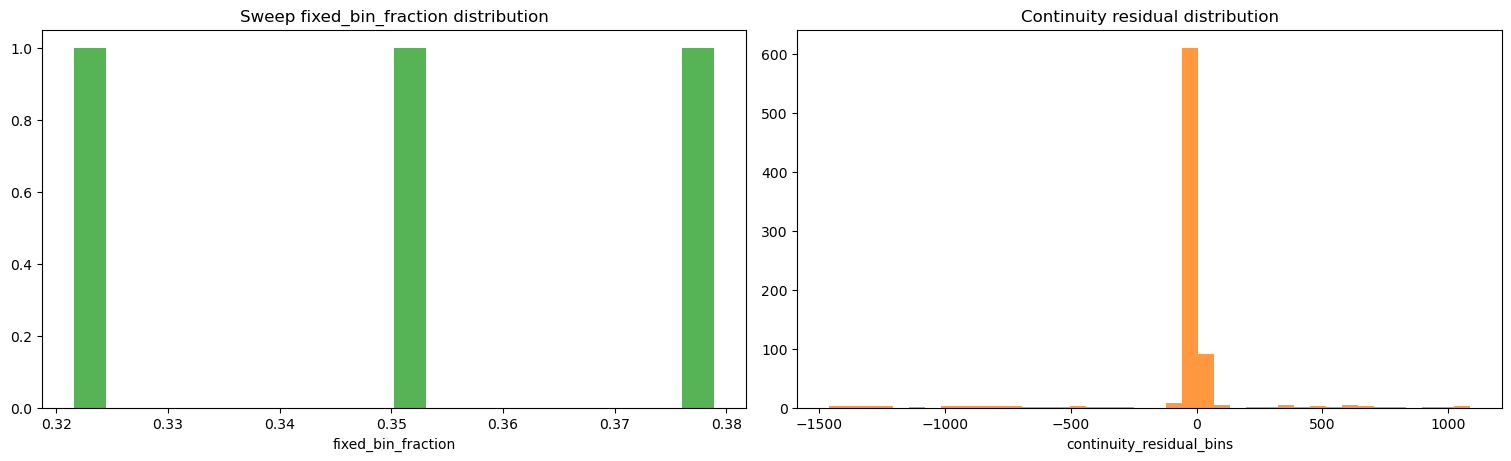

,h5_filename,sweep_num,n_tracks,n_valid_pulses,median_refh_snr,fraction_good_snr,median_main_peak_prominence,median_main_peak_width_bins,median_n_candidate_components,median_n_prominent_components,fraction_clear_main_peak,fraction_valid_secondary_peak,fraction_weak_main_peak,fraction_broad_main_peak,fixed_bin_mode,fixed_bin_fraction,stripe_like_flag,continuity_median_abs_residual,continuity_p95_abs_residual,continuity_discontinuity_count
0,casals_l1b_20241118T171757_001_02.h5,5000,256,256,3.838088,0.375000,1019.409073,8.571498,4.0,2.0,0.375000,0.535156,0.000000,0.0,1693.0,0.378906,True,1.0,375.5,64
1,casals_l1b_20241118T171757_001_02.h5,5001,256,256,3.919184,0.347656,1048.391920,8.933250,3.0,1.0,0.347656,0.468750,0.003906,0.0,1693.0,0.352941,True,1.0,313.3,75
2,casals_l1b_20241118T171757_001_02.h5,5002,256,256,3.645453,0.355469,995.498153,8.563601,4.0,2.0,0.355469,0.542969,0.003906,0.0,1694.0,0.321569,True,1.0,761.2,75


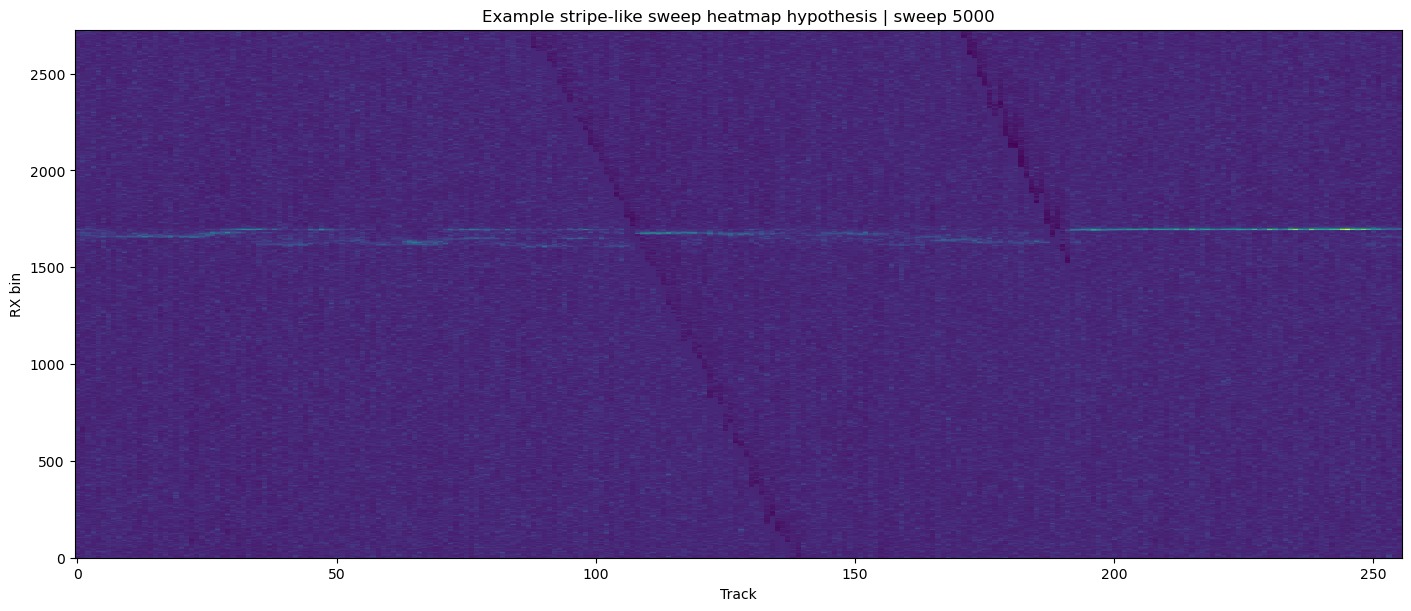

In [5]:
display(sweep_df.sort_values("fixed_bin_fraction", ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True)
axes[0].hist(sweep_df["fixed_bin_fraction"].dropna(), bins=20, color="tab:green", alpha=0.8)
axes[0].set_title("Sweep fixed_bin_fraction distribution")
axes[0].set_xlabel("fixed_bin_fraction")

axes[1].hist(pulse_df["continuity_residual_bins"].dropna(), bins=40, color="tab:orange", alpha=0.8)
axes[1].set_title("Continuity residual distribution")
axes[1].set_xlabel("continuity_residual_bins")
plt.show()

stripe_rows = sweep_df.loc[sweep_df["stripe_like_flag"].fillna(False)]
if stripe_rows.empty:
    print("No stripe-like sweep was flagged in the current sample output.")
else:
    display(stripe_rows.head())
    stripe_sweep = int(stripe_rows.iloc[0]["sweep_num"])
    h5_path = CASALS_L1B_DIR / "casals_h5_downloads" / f"{H5_STEM}.h5"
    with h5py.File(h5_path, "r") as h5:
        index_info = build_record_index_grid(h5)
        rx_matrix, _, _ = read_sweep_matrix(h5, "rx_waveform", stripe_sweep, index_info)
    fig, ax = plt.subplots(figsize=(14, 6), constrained_layout=True)
    ax.imshow(rx_matrix.T, aspect="auto", origin="lower", cmap="viridis", interpolation="nearest")
    ax.set_title(f"Example stripe-like sweep heatmap hypothesis | sweep {stripe_sweep}")
    ax.set_xlabel("Track")
    ax.set_ylabel("RX bin")
    plt.show()

## Main result D: join with 3DEP pseudo-labels if available

In [6]:
candidate_label_paths = []
candidate_label_paths.extend((CASALS_L1B_DIR / "outputs" / "transfer_3dep_labels_to_casals").glob(f"{H5_STEM}*.la?"))
candidate_label_paths.extend((CASALS_L1B_DIR / "outputs" / "classify_and_evaluate_casals_refh").glob(f"{H5_STEM}*.la?"))

label_path = next((path for path in candidate_label_paths if path.exists()), None)
if label_path is None:
    print("No transferred 3DEP pseudo-label file found; skipping pseudo-label analysis.")
else:
    print("Using pseudo-label file:", label_path)
    las = laspy.read(label_path)
    if "point_index" not in las.point_format.dimension_names:
        print("Pseudo-label file has no point_index extra dimension; skipping pseudo-label analysis.")
    else:
        label_df = pd.DataFrame(
            {
                "pulse_index": np.asarray(las["point_index"], dtype=np.int64),
                "pseudo_label_class": np.asarray(las.classification, dtype=np.uint8),
            }
        )
        joined = pulse_df.merge(label_df, on="pulse_index", how="inner")
        display(joined.groupby("pseudo_label_class")[["main_peak_prominence", "main_peak_width_bins"]].agg(["count", "median", "mean"]))
        display(joined.groupby(["pseudo_label_class", "waveform_reliability_class"]).size().unstack(fill_value=0))
        display(joined.groupby("pseudo_label_class")[["fixed_bin_stripe_score", "continuity_residual_bins"]].agg(["median", "mean"]))

Using pseudo-label file: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\transfer_3dep_labels_to_casals\casals_l1b_20241118T171757_001_02.laz


main_peak_prominence                            \
                                  count       median         mean   
pseudo_label_class                                                  
1                                   357   877.171491   975.087581   
2                                   281  1935.494089  1975.046494   
7                                   128   630.873429   705.846816   

                   main_peak_width_bins                        
                                  count     median       mean  
pseudo_label_class                                             
1                                   357  10.479626  11.717908  
2                                   281   8.040657   8.095211  
7                                   128   7.926012   9.366972

waveform_reliability_class,ambiguous_main_peak,clear_main_peak,clear_main_with_secondary_candidate,no_detected_main_peak
pseudo_label_class,,,,
1,132,30,195,0
2,19,137,125,0
7,50,2,76,2


fixed_bin_stripe_score           continuity_residual_bins  \
                                   median      mean                   median   
pseudo_label_class                                                             
1                                0.352941  0.350951                      0.0   
2                                0.352941  0.351948                      0.0   
7                                0.352941  0.349904                     -5.0   

                                
                          mean  
pseudo_label_class              
1                    -0.782913  
2                       2.8879  
7                  -125.898438

## Representative examples

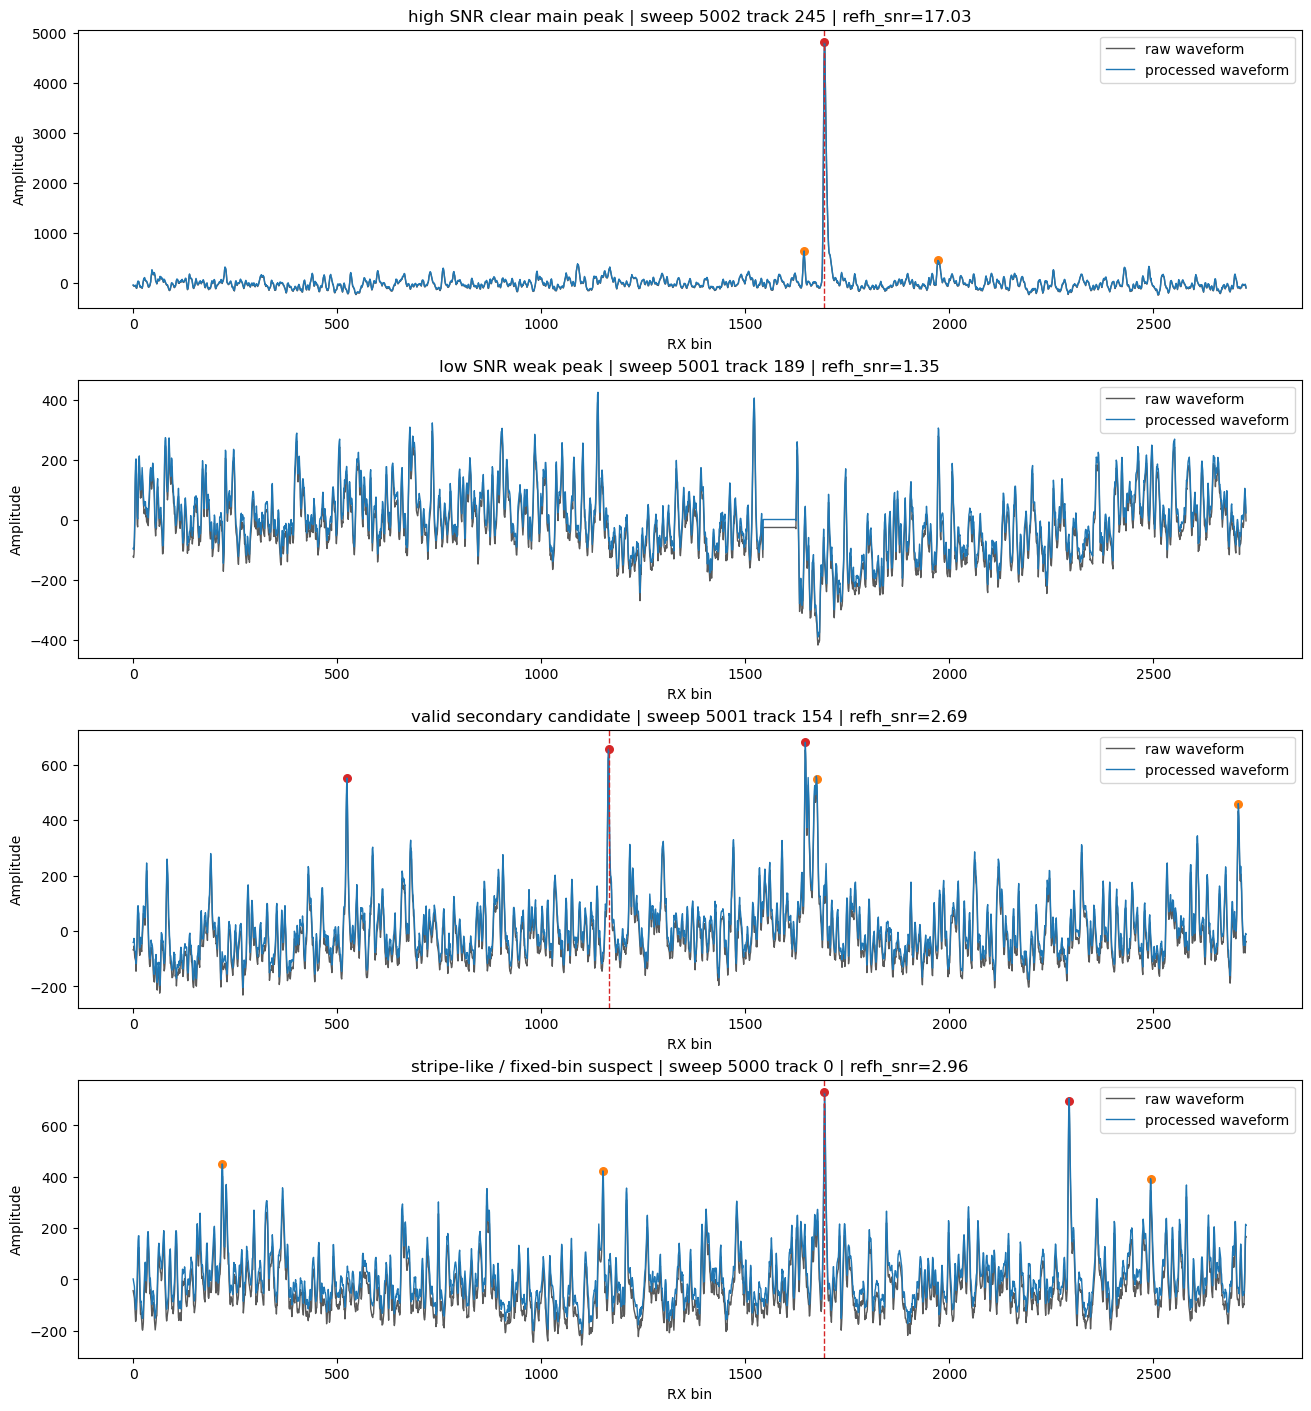

In [7]:
example_specs = []

def add_example(frame: pd.DataFrame, label: str) -> None:
    if frame.empty:
        return
    example_specs.append((label, frame.iloc[0]))

add_example(pulse_df.loc[pulse_df["has_clear_main_peak"].fillna(False)].sort_values("refh_snr", ascending=False), "high SNR clear main peak")
add_example(pulse_df.loc[pulse_df["has_weak_main_peak"].fillna(False)].sort_values("refh_snr", ascending=True), "low SNR weak peak")
add_example(pulse_df.loc[pulse_df["has_broad_main_peak"].fillna(False)].sort_values("main_peak_width_bins", ascending=False), "broad peak")
add_example(pulse_df.loc[pulse_df["has_valid_secondary_peak"].fillna(False)].sort_values("secondary_to_main_prominence_ratio", ascending=False), "valid secondary candidate")

stripe_pulses = pulse_df.loc[pulse_df["fixed_bin_stripe_score"].astype(float) >= 0.20]
add_example(stripe_pulses.sort_values("fixed_bin_stripe_score", ascending=False), "stripe-like / fixed-bin suspect")

if not example_specs:
    print("No representative examples were found in the current pulse summary.")
else:
    h5_path = CASALS_L1B_DIR / "casals_h5_downloads" / f"{H5_STEM}.h5"
    with h5py.File(h5_path, "r") as h5:
        index_info = build_record_index_grid(h5)
        fields = {
            name: read_optional_1d(h5, name, index_info.n_records, dtype=(bool if name == "good_snr" else np.float64))
            for name in ["bg_mean", "bg_std", "refh_thres", "refh_snr", "good_snr", "refh_amp"]
        }
        n_rows = len(example_specs)
        fig, axes = plt.subplots(n_rows, 1, figsize=(13, 3.5 * n_rows), constrained_layout=True)
        axes = np.atleast_1d(axes)
        for ax, (label, row) in zip(axes, example_specs):
            sweep_num = int(row["sweep_num"])
            track_num = int(row["track_num"])
            rx_matrix, _, record_indices = read_sweep_matrix(h5, "rx_waveform", sweep_num, index_info)
            pulse_index = int(record_indices[track_num])
            waveform = rx_matrix[track_num].astype(np.float64)
            components = component_df.loc[(component_df["pulse_index"] == pulse_index)].copy()
            raw = waveform
            corrected = waveform - float(fields["bg_mean"][pulse_index])
            refh_snr_value = pd.to_numeric(pd.Series([row["refh_snr"]]), errors="coerce").iloc[0]
            main_peak_value = pd.to_numeric(pd.Series([row["main_peak_bin"]]), errors="coerce").iloc[0]
            ax.plot(raw, color="0.35", linewidth=1.0, label="raw waveform")
            ax.plot(corrected, color="tab:blue", linewidth=1.0, label="processed waveform")
            for _, comp in components.iterrows():
                color = "tab:red" if bool(comp["is_prominent_component"]) else "tab:orange"
                ax.scatter(comp["peak_bin"], comp["amplitude_processed"], s=30, color=color)
            if pd.notna(main_peak_value):
                ax.axvline(float(main_peak_value), color="tab:red", linestyle="--", linewidth=1.0)
            ax.set_title(
                f"{label} | sweep {sweep_num} track {track_num} | "
                f"refh_snr={refh_snr_value:.2f}" if pd.notna(refh_snr_value) else f"{label} | sweep {sweep_num} track {track_num} | refh_snr=NA"
            )
            ax.set_xlabel("RX bin")
            ax.set_ylabel("Amplitude")
            ax.legend(loc="upper right")
        plt.show()

## Final interpretation

Report-ready summary:
- Useful waveform-derived features: main peak prominence, main peak width, weak/broad peak flags, secondary-to-main prominence ratio after prominent-component filtering, continuity residuals, and fixed-bin stripe fraction.
- Not useful yet as standalone science claims: raw candidate component count without filtering, or tentative bin-to-height offsets interpreted as physical secondary returns.
- This workflow does not support claims that secondary peaks are georeferenced returns or an official multi-return point cloud.
- These features can support downstream refh filtering/classification by flagging weak, broad, discontinuous, or stripe-like waveform behavior.